In [1]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pickle
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

In [2]:
#Load Data

#Load Dataset
print("Lets inport the Datasets........\n")
df = pd.read_csv("Data set/student_dataset.csv")

df.head()

Lets inport the Datasets........



,StudentID,Gender,Age,StudyHours,Attendance,ParentalEducation,PreviousMarks,ExtraClasses,SleepHours,InternetAccess,SchoolSupport,Semester1,Semester2,Semester3,Semester4,FinalMarks
0,1,Male,16,1.9,87,Bachelor's,60,Yes,6.9,Yes,Yes,58,59,50,52,53
1,2,Female,17,3.7,66,High School,86,No,8.2,Yes,Yes,58,69,62,59,58
2,3,Male,15,5.4,94,Bachelor's,73,Yes,5.7,No,Yes,72,67,78,71,71
3,4,Male,15,4.7,87,Bachelor's,94,No,5.4,Yes,No,73,70,76,71,74
4,5,Male,15,5.0,73,High School,70,Yes,8.5,Yes,No,62,74,68,64,66


In [3]:
#Encode the Gender Column

lb = LabelEncoder()
df['Gender'] = lb.fit_transform(df['Gender'])
print("Transform the Gender column is completed.")

Transform the Gender column is completed.


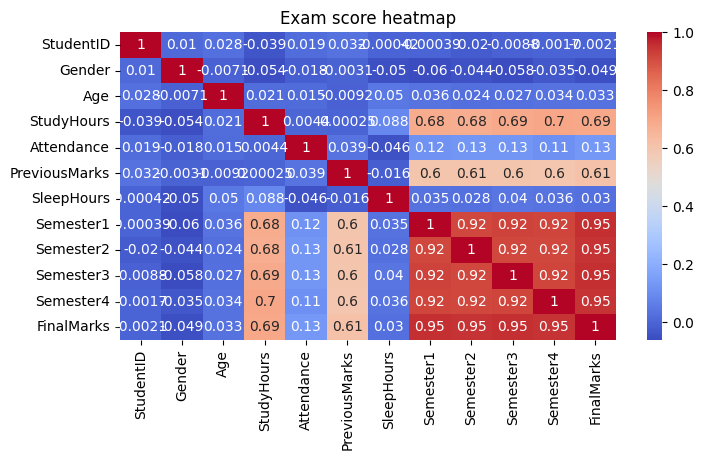

In [4]:
#Corelatino Code

coorelation = df.corr(numeric_only=True)

#Check the Heatmap for the Correlatino

plt.figure(figsize=(8,4))
sns.heatmap(coorelation,annot=True,cmap='coolwarm')
plt.title("Exam score heatmap")
plt.show()

In [5]:
#Drop the Unwanted Columns

df.drop(columns=['StudentID','Gender','Age','Attendance','SleepHours'])


,StudyHours,ParentalEducation,PreviousMarks,ExtraClasses,InternetAccess,SchoolSupport,Semester1,Semester2,Semester3,Semester4,FinalMarks
0,1.9,Bachelor's,60,Yes,Yes,Yes,58,59,50,52,53
1,3.7,High School,86,No,Yes,Yes,58,69,62,59,58
2,5.4,Bachelor's,73,Yes,No,Yes,72,67,78,71,71
3,4.7,Bachelor's,94,No,Yes,No,73,70,76,71,74
4,5.0,High School,70,Yes,Yes,No,62,74,68,64,66
...,...,...,...,...,...,...,...,...,...,...,...
995,4.3,Master's,86,No,Yes,Yes,68,76,67,69,73
996,5.8,Master's,43,Yes,Yes,Yes,62,59,65,63,61
997,1.3,Master's,90,No,Yes,Yes,56,54,61,52,56
998,1.3,High School,60,Yes,Yes,Yes,47,44,44,47,46


In [6]:
print("Selecting input features and target variable for model training...\n")

fetures = [
    'StudyHours',
    'PreviousMarks',
    'Semester1',
    'Semester2',
    'Semester3',
    'Semester4'
]
x = df[fetures]
y = df['FinalMarks']

x_train, x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.8)


Selecting input features and target variable for model training...



In [7]:
#We are use the Random Forest Regression model for this prediction

try:    
    print("Lets Train the RandomForest Regressorn Model for this datasets.................\n")
    #Train Model 
    rfmodel = RandomForestRegressor()
    rfmodel.fit(x,y)
    predicted_score = rfmodel.predict(x)
except Exception as e:
    print(f"Error {e}.")

Lets Train the RandomForest Regressorn Model for this datasets.................



In [8]:
#Use Linear Regression Model
# from sklearn.linear_model import LinearRegression
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.neighbors import KNeighborsRegressor

mdls = {
    'Random Forest':RandomForestRegressor(),
    'linear Regression': LinearRegression(),
    'Dtree': DecisionTreeRegressor(),
    'KNN' : KNeighborsRegressor()
}

#Save All Model Performance
model_score = {}

for i,Model in mdls.items():
    
    Model.fit(x_train,y_train)

    y_pred = Model.predict(x_test)

    print(f"For the {Model}:")
    mae = mean_absolute_error(y_test,y_pred)
    mse = mean_squared_error(y_test,y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test,y_pred)

    #Save performacne
    model_score[i] = {
        'model':Model,
        'r2':r2,
        'rmse':rmse
    }

    print(f"Mean Absolute Error (MAE): {round(mae, 2)}")
    print(f"Mean Squared Error (MSE): {round(mse, 2)}")
    print(f"Root Mean Squared Error (RMSE): {round(rmse, 2)}")
    print(f"R² Score (Model Accuracy): {round(r2 * 100, 2)}%")
    print("=====================================================")
    print()
    
#Best Model Selection

best_model_name = max(model_score,key= lambda x: model_score[x]['r2'])
best_model = model_score[best_model_name]['model']
best_model_accuracy = model_score[best_model_name]['r2']

For the RandomForestRegressor():
Mean Absolute Error (MAE): 1.85
Mean Squared Error (MSE): 5.37
Root Mean Squared Error (RMSE): 2.32
R² Score (Model Accuracy): 95.12%

For the LinearRegression():
Mean Absolute Error (MAE): 1.62
Mean Squared Error (MSE): 4.09
Root Mean Squared Error (RMSE): 2.02
R² Score (Model Accuracy): 96.28%

For the DecisionTreeRegressor():
Mean Absolute Error (MAE): 2.62
Mean Squared Error (MSE): 11.3
Root Mean Squared Error (RMSE): 3.36
R² Score (Model Accuracy): 89.73%

For the KNeighborsRegressor():
Mean Absolute Error (MAE): 1.93
Mean Squared Error (MSE): 6.15
Root Mean Squared Error (RMSE): 2.48
R² Score (Model Accuracy): 94.41%



In [9]:
try:
    print("User Input Fields.........\n")

    # study_hours = float(input("Enter Study Hours: "))
    # previous_marks = float(input("Enter Previous Marks: "))
    # semester1 = float(input("Enter Semester 1 Marks: "))
    # semester2 = float(input("Enter Semester 2 Marks: "))
    # semester3 = float(input("Enter Semester 3 Marks: "))
    # semester4 = float(input("Enter Semester 4 Marks: "))

    study_hours = 30
    previous_marks = 75
    semester1 = 70
    semester2 = 80
    semester3 = 65
    semester4 = 60
    
    user_data = [study_hours,previous_marks,semester1,semester2,semester3,semester4]
    
    user_data = pd.DataFrame([user_data])

    final_prediction = best_model.predict(user_data)[0]

    print(f"The Final Prediction output is : {round(final_prediction,2)}%")
except Exception as e:
    print(f"Error {e}")

User Input Fields.........

The Final Prediction output is : 75.49%


c:\Users\Krushn\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [10]:
# Academic Performance Report

semester_avg = (semester1 + semester2 + semester3 + semester4) / 4

print("\n" + "="*50)
print("      ACADEMIC PERFORMANCE REPORT")
print("="*50)

print(f"Predicted Final Marks      : {round(final_prediction, 2)}")
print(f"Average Semester Marks     : {round(semester_avg, 2)}")

# Performance Category

if final_prediction >= 85:
    category = "Excellent"
elif final_prediction >= 70:
    category = "Good"
elif final_prediction >= 50:
    category = "Average"
else:
    category = "At Risk"

print(f"Performance Category       : {category}")

print("\nRecommendations:")
print("-" * 50)

recommendation_found = False

if study_hours < 4:
    print("• Increase daily study hours to at least 4-5 hours.")
    recommendation_found = True

if previous_marks < 60:
    print("• Strengthen fundamental concepts and revise previous topics.")
    recommendation_found = True

if semester_avg < 65:
    print("• Revise previous semester subjects regularly.")
    recommendation_found = True

if final_prediction < 50:
    print("• Seek additional academic support and mentoring.")
    print("• Solve more practice papers and mock tests.")
    recommendation_found = True

elif final_prediction >= 50 and final_prediction < 70:
    print("• Maintain consistency in studies and improve weak subjects.")
    recommendation_found = True

elif final_prediction >= 70 and final_prediction < 85:
    print("• Good performance. Focus on advanced practice and revision.")
    recommendation_found = True

elif final_prediction >= 85:
    print("• Excellent performance!")
    print("• Maintain your current study routine.")
    print("• Challenge yourself with advanced topics and competitive exams.")
    recommendation_found = True

if not recommendation_found:
    print("• Keep up the good work and continue learning.")

print("="*50)


      ACADEMIC PERFORMANCE REPORT
Predicted Final Marks      : 75.49
Average Semester Marks     : 68.75
Performance Category       : Good

Recommendations:
--------------------------------------------------
• Good performance. Focus on advanced practice and revision.


In [11]:
try:
    print("Lets make the pickle model for this projects.............\n")

    md = {
    'bst_model': best_model,
    'bst_accuracy':best_model_accuracy
    }

    with open('models/model.pkl','wb') as f:
        pickle.dump(md,f)
except Exception as e:
    print(f"Error {e}")

Lets make the pickle model for this projects.............



Disrtibution of FINAL EXAM SCORE



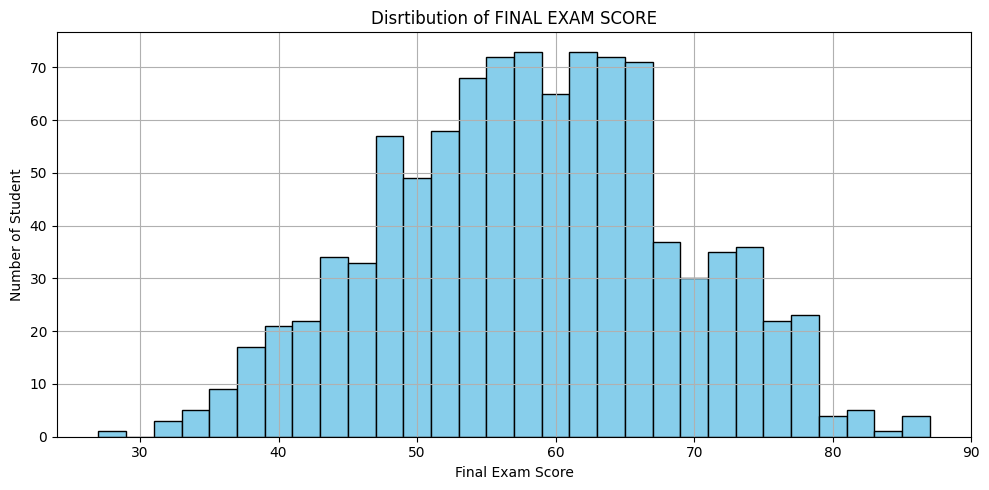

In [12]:
try:
    #Histogram Chart
    print("Disrtibution of FINAL EXAM SCORE\n")
    plt.figure(figsize=(10,5))
    plt.hist(df["FinalMarks"],bins=30,color="skyblue",edgecolor="black")
    plt.title("Disrtibution of FINAL EXAM SCORE")
    plt.xlabel("Final Exam Score")
    plt.ylabel("Number of Student")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('Diagram Images/Disrtibution_of_FINAL_EXAM_SCORE.png', dpi=400, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Error {e}")

Model Prediction vs Actual Score



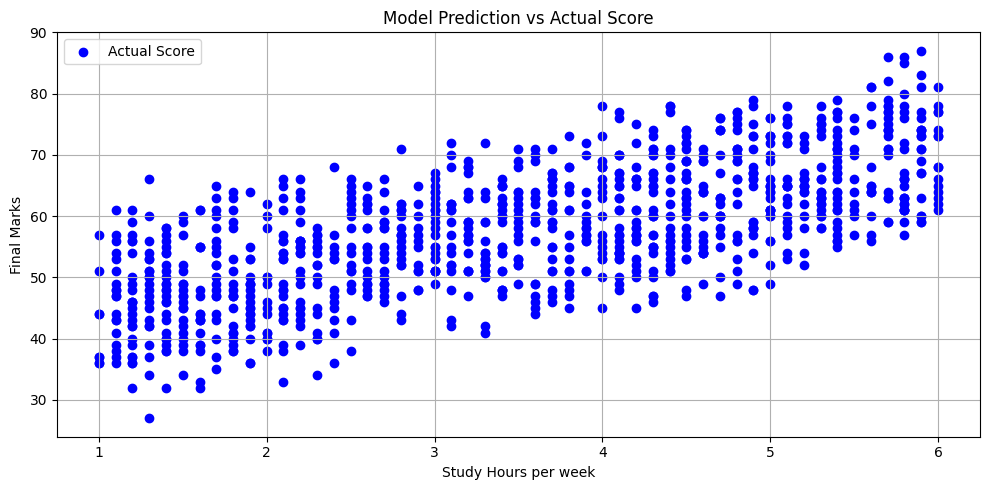

In [13]:
try:
    #Scatter + Regression Line
    print("Model Prediction vs Actual Score\n")
    plt.figure(figsize=(10,5))
    plt.scatter(df[["StudyHours"]], df[["FinalMarks"]], color="blue", label="Actual Score")
    plt.title("Model Prediction vs Actual Score")
    plt.xlabel("Study Hours per week")
    plt.ylabel("Final Marks")
    plt.grid(True)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig('Diagram Images/Model_Prediction_vs_Actual_Score.png', dpi=400, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Error {e}")